## SHAP Explainability

**Goal:** Explain WHY the model makes each prediction.

**Input:** Trained XGBoost model + test data  
**Output:** Global and local explanations of fraud predictions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib

In [2]:
model = joblib.load('../models/xgboost.pkl')

X_test = pd.read_csv('../data/processed/X_test.csv')
Y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Genuine in test set: {(Y_test==0).sum()}")
print(f"Fraud in test set  : {(Y_test==1).sum()}")

print("Model and data loaded successfully!")
print(f"Test data shape: {X_test.shape}")

Genuine in test set: 71079
Fraud in test set  : 123
Model and data loaded successfully!
Test data shape: (71202, 30)


### SHAP (SHapley Additive exPlanations)

SHAP is an explainable AI (XAI) technique used to understand how a machine learning model makes predictions. It assigns an importance value (SHAP value) to each feature, showing how much it contributes to increasing or decreasing the model's prediction.

In this project, SHAP is used to interpret the XGBoost model and identify which features have the greatest influence on detecting fraudulent transactions.

In [3]:
explainer = shap.TreeExplainer(model)
print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [4]:
fraud_idx = Y_test[Y_test==1].index
genuine_idx = Y_test[Y_test==0].sample(877, random_state=42).index
sample_idx = fraud_idx.union(genuine_idx)

X_sample = X_test.loc[sample_idx]
Y_sample = Y_test.loc[sample_idx]

shap_values = explainer.shap_values(X_sample)

print(f"Genuine in sample: {(Y_sample==0).sum()}")
print(f"Fraud in sample  : {(Y_sample==1).sum()}")
print("SHAP values calculated successfully!")
print(f"Shape: {shap_values.shape}")

Genuine in sample: 877
Fraud in sample  : 123
SHAP values calculated successfully!
Shape: (1000, 30)


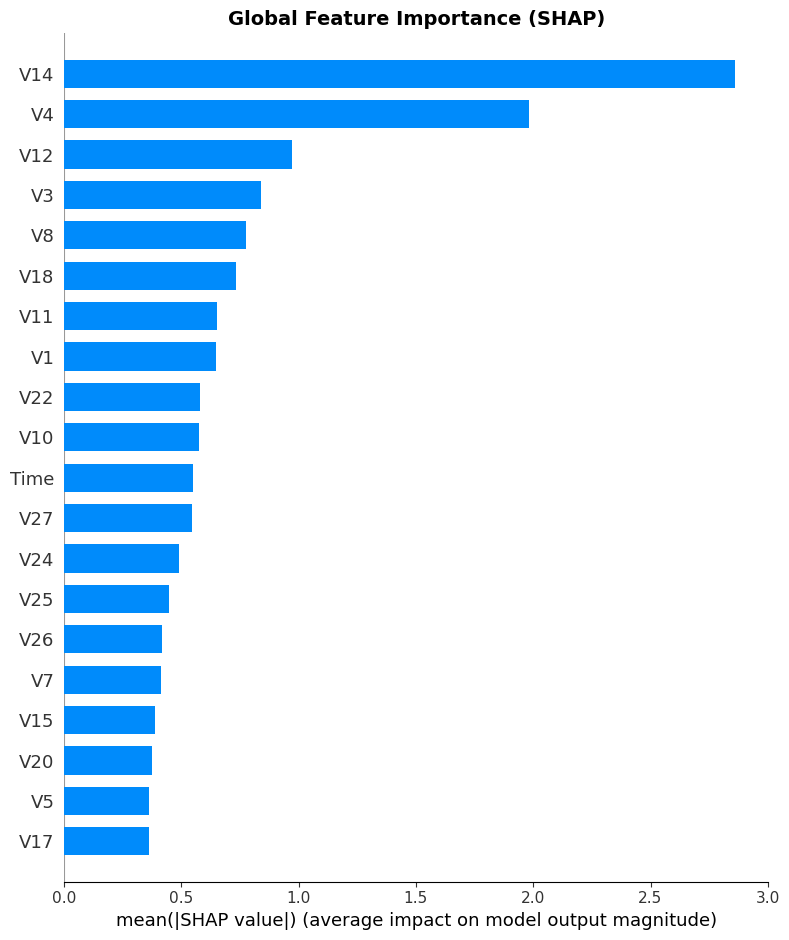

In [5]:
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('Global Feature Importance (SHAP)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### What This Chart Shows

This bar chart ranks the top 20 features by their average impact 
on the model's output, across 1000 sample transactions. It tells you 
WHICH features the model relies on most — not whether those 
features push predictions toward fraud or toward genuine.

**Top 3 features:** V14, V4, V12

**Important note:** A long bar means the model pays a lot of 
attention to that feature when making decisions. It does NOT tell 
you the direction of that effect (fraud vs genuine) — only that 
the feature matters. The next chart (beeswarm plot) shows direction.

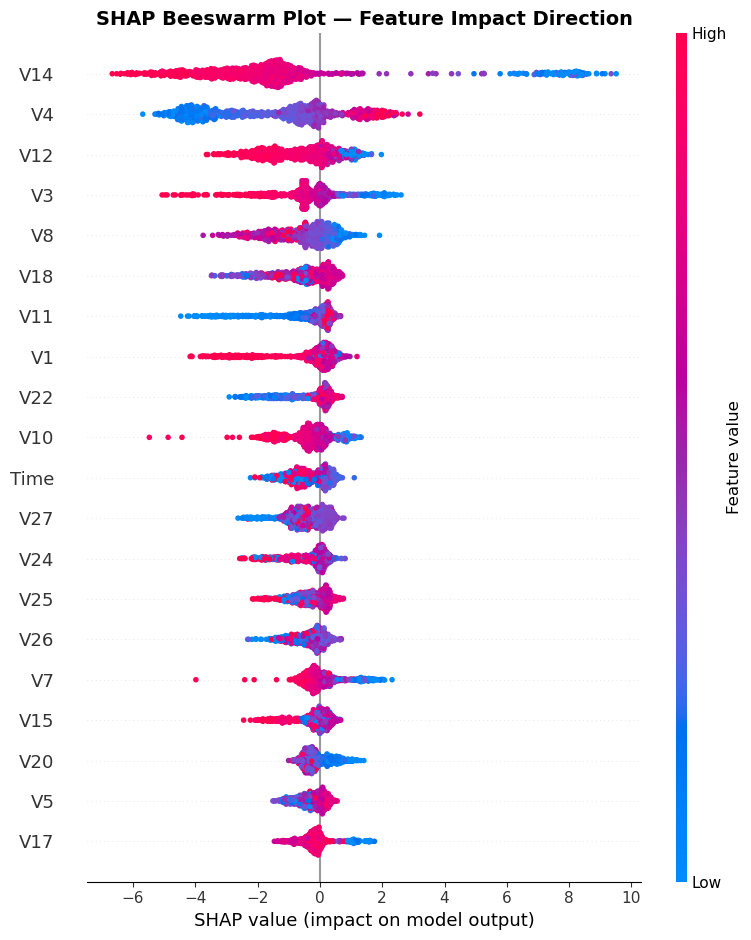

In [6]:
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type='dot', show=False)
plt.title('SHAP Beeswarm Plot — Feature Impact Direction', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

### SHAP Beeswarm Insights

This plot shows two things at once for every feature: how much it 
matters, and whether high or low values of it push a prediction 
toward fraud or genuine.

**How to read this plot:**

| Element | Meaning |
|---------|---------|
| Each dot | One transaction from the sample |
| Row position (top to bottom) | Features ranked by overall importance |
| X-axis position | Direction and strength of impact on the prediction |
| Right side of center (0) | Pushes prediction toward **fraud** |
| Left side of center (0) | Pushes prediction toward **genuine** |
| Distance from 0 | How strongly that feature mattered for that transaction |
| 🔴 Red dot | Feature had a **high** value for that transaction |
| 🔵 Blue dot | Feature had a **low** value for that transaction |

**Key patterns found:**
- **V14** — blue dots (low values) cluster on the right → low V14 
  pushes predictions toward fraud. Red dots (high values) cluster 
  on the left → high V14 pushes toward genuine.
- **V4** — opposite pattern: red dots (high values) push toward 
  fraud, blue dots (low values) push toward genuine.
- **V12, V3** — same pattern as V14: low values push toward fraud.

### Individual Transaction Explanation — Why This Transaction?
Global importance tells us what matters overall. Now we explain 
ONE specific fraud transaction — exactly what a fraud analyst 
would need to see before confirming or rejecting a fraud alert.

Explaining transaction at index: 346
Actual label: Fraud
Model's predicted probability: 0.9999


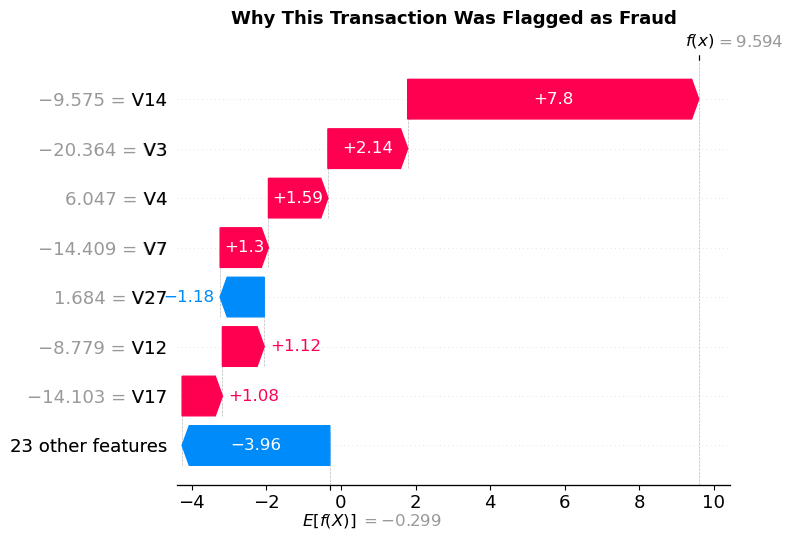

In [7]:
fraud_index_in_sample = Y_sample[Y_sample == 1].index[0]
position = X_sample.index.get_loc(fraud_index_in_sample)

print(f"Explaining transaction at index: {fraud_index_in_sample}")
print(f"Actual label: Fraud")
print(f"Model's predicted probability: {model.predict_proba(X_sample.loc[[fraud_index_in_sample]])[:,1][0]:.4f}")

shap.plots.waterfall(
    shap.Explanation(values=shap_values[position],
                      base_values=explainer.expected_value,
                      data=X_sample.iloc[position],
                      feature_names=X_sample.columns.tolist()),
                      max_display=8,
                      show=False
)
plt.title('Why This Transaction Was Flagged as Fraud', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/shap_waterfall_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

#### Explaining One Fraud Transaction from graph

While the SHAP Summary Plot explains the model's behavior across the entire dataset, the SHAP Waterfall Plot explains **one specific prediction**. It shows how each feature of an individual transaction contributes to the model's final decision.

The explanation starts from the **base value (E[f(X)])**, which represents the model's average output before considering any feature values. Each feature then either **increases** or **decreases** the prediction:

- **Red bars** represent features that push the prediction **towards fraud** (positive SHAP values).
- **Blue bars** represent features that push the prediction **towards genuine** (negative SHAP values).

The value shown on the **left** (e.g., `-9.575 = V14`) is the **actual feature value** for that transaction, while the value displayed on the **bar** (e.g., `+7.8`) is the **SHAP value**, indicating how much that feature influenced the prediction.

The final value **f(x)** shown at the top-right is the model's final output for that transaction after combining the contributions of all features. This visualization helps explain **why the model classified this specific transaction as fraud**, making the prediction transparent and easier for fraud analysts to understand and verify.

#### Findings for This Specific Transaction

Based on the waterfall plot for this fraud transaction:
- **V14** had the strongest impact — its **very low value (V14 = -9.575)** pushed the prediction strongly toward fraud (largest red bar).
- **V4** also contributed significantly toward fraud prediction
- The base value started near 0 (average prediction) but feature contributions pushed the final output f(x) close to 1.0 — confirming high fraud probability

This shows the model is not making a random guess — it has specific, traceable reasons for flagging this transaction.